# World Internet Adoption Analysis (1990–2024)

A multi-lens exploration of global internet growth:     
     
A. Adoption curve with milestone annotations     
B. Year-over-year growth rate & phase segmentation     
C. Logistic (S-curve) model fitting & projection     
D. Digital divide: connected to internet vs. unconnected to internet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit

### Load Data & Merge Historical Data

In [2]:
# 1. LOAD & MERGE
internet = pd.read_csv(r"C:\Users\INDAH NAINGGOLAN\Data\world-internet-users.csv")
population = pd.read_csv(r"C:\Users\INDAH NAINGGOLAN\Data\historical-world-population.csv")
 
df = internet.merge(population, on="year", how="left")

In [3]:
df

,year,internet_users,population
0,1990,3000000,5.327803e+09
1,1991,4000000,5.418736e+09
2,1992,7000000,5.505990e+09
3,1993,10000000,5.591545e+09
4,1994,20000000,5.675551e+09
5,1995,39000000,5.758879e+09
6,1996,77000000,5.842056e+09
7,1997,120000000,5.924788e+09
8,1998,188000000,6.007067e+09
9,1999,281000000,6.089006e+09


Because there is no data of population for year 2023-2024, we decide to extrapolate the data. Population values were linearly extrapolated based on the average annual growth observed in the three preceding years (2020–2022).

In [4]:
# Extrapolate population for 2023–2024 (linear trend from last 3 years)
pop_recent = df.loc[df["year"].isin([2020, 2021, 2022]), "population"]
annual_growth = pop_recent.diff().mean()
for yr in [2023, 2024]:
    if df.loc[df["year"] == yr, "population"].isna().any():
        prev_pop = df.loc[df["year"] == yr - 1, "population"].values[0]
        df.loc[df["year"] == yr, "population"] = prev_pop + annual_growth
 
df = df.dropna(subset=["population"])

In [5]:
df.describe()

,year,internet_users,population
count,35.000000,3.500000e+01,3.500000e+01
mean,2007.000000,1.899314e+09,6.770083e+09
std,10.246951,1.818033e+09,8.674723e+08
min,1990.000000,3.000000e+06,5.327803e+09
25%,1998.500000,2.345000e+08,6.048037e+09
50%,2007.000000,1.372000e+09,6.757309e+09
75%,2015.500000,3.130500e+09,7.514523e+09
max,2024.000000,5.450000e+09,8.155813e+09


In [6]:
print("DATASET OVERVIEW")
print(f"  Time span       : {df['year'].min()} – {df['year'].max()}")
print(f"  Users in 1990   : {df.iloc[0]['internet_users']:,.0f}")
print(f"  Users in 2024   : {df.iloc[-1]['internet_users']:,.0f}")
print(f"  Growth factor   : {df.iloc[-1]['internet_users'] / df.iloc[0]['internet_users']:,.0f}×")

DATASET OVERVIEW
  Time span       : 1990 – 2024
  Users in 1990   : 3,000,000
  Users in 2024   : 5,450,000,000
  Growth factor   : 1,817×


The internet users ranged from 3 million (1990) to 5.45 billion (2024), with median 1.37 billion, which means that for half observed years, global users were still below 1.4 billion. It reflecting how recent the mass adoption of internet.

The high standard deviation (1.82 billion) confirms that the data of interenet users is widely spread and not clustered around the mean.

### Phase Statistics

Next, we calculate the ***penetration rate*** to show the percentage of the total world population that has internet access in a given year. We also calculate the ***unconnected population***, which represents the number of people on Earth who do not have internet access in a given year.

To make the growth pattern easier to understand, we segment the data by the dominant growth mechanism of each era so that patterns become more comparable within each phase. Each phase represents:
1. **Pioneer (1990–1999)**: The era in which the internet was not yet a consumer product and was limited only to early tech enthusiasts.
2. **Expansion (2000–2009)**: The era in which the internet became a mainstream product for households and businesses in developed countries. It was also the era when social media emerged, with Facebook launching in 2004 and YouTube in 2005.
3. **Maturation (2010–2024)**: The era in which internet growth shifted from developed to emerging markets, driven largely by the availability of affordable smartphones and mobile data.

In [7]:
# 2. PHASE SEGMENTATION
df["penetration"] = (df["internet_users"] / df["population"] * 100).round(2)
df["unconnected"] = df["population"] - df["internet_users"]
df["yoy_growth"] = df["internet_users"].pct_change() * 100
df["abs_growth"] = df["internet_users"].diff()
 
# Phase labels
def classify_phase(year):
    if year <= 1999:
        return "Pioneer (1990–99)"
    elif year <= 2009:
        return "Expansion (2000–09)"
    else:
        return "Maturation (2010–24)"
 
df["phase"] = df["year"].apply(classify_phase)

In [8]:
# Phase Statistics
print("GROWTH BY PHASE")
for phase_name, group in df.groupby("phase", sort=False):
    avg_yoy = group["yoy_growth"].mean()
    total_added = group["abs_growth"].sum()
    print(f"  {phase_name}")
    print(f"    Avg YoY growth : {avg_yoy:.1f}%")
    print(f"    Users added    : {total_added / 1e9:.2f}B")
    print()
    
print(f"  Peak penetration: {df['penetration'].max():.1f}% ({df.loc[df['penetration'].idxmax(), 'year']})")
first_billion = df.loc[df["internet_users"] >= 1e9].iloc[0]
print(f"  First billion   : {int(first_billion['year'])}")

GROWTH BY PHASE
  Pioneer (1990–99)
    Avg YoY growth : 67.3%
    Users added    : 0.28B

  Expansion (2000–09)
    Avg YoY growth : 20.6%
    Users added    : 1.49B

  Maturation (2010–24)
    Avg YoY growth : 7.8%
    Users added    : 3.68B

  Peak penetration: 66.8% (2024)
  First billion   : 2005


Text(0, 0.5, 'Penetration (Percent Connected)')

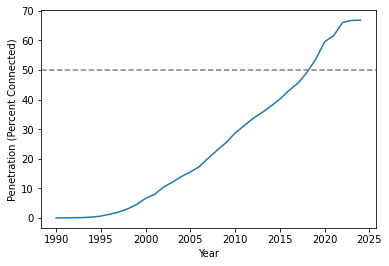

In [9]:
plt.plot(df["year"], df["penetration"])
plt.axhline(50, color="gray", linestyle="--")
plt.xlabel("Year")
plt.ylabel("Penetration (Percent Connected)")

### Logistic Model Fitting

Based on the previous graph, we can see that the growth of Internet adoption has a slow start and a rapid acceleration in the middle. Therefore, we use the logistic model under the assumption that internet growth follows this same pattern.

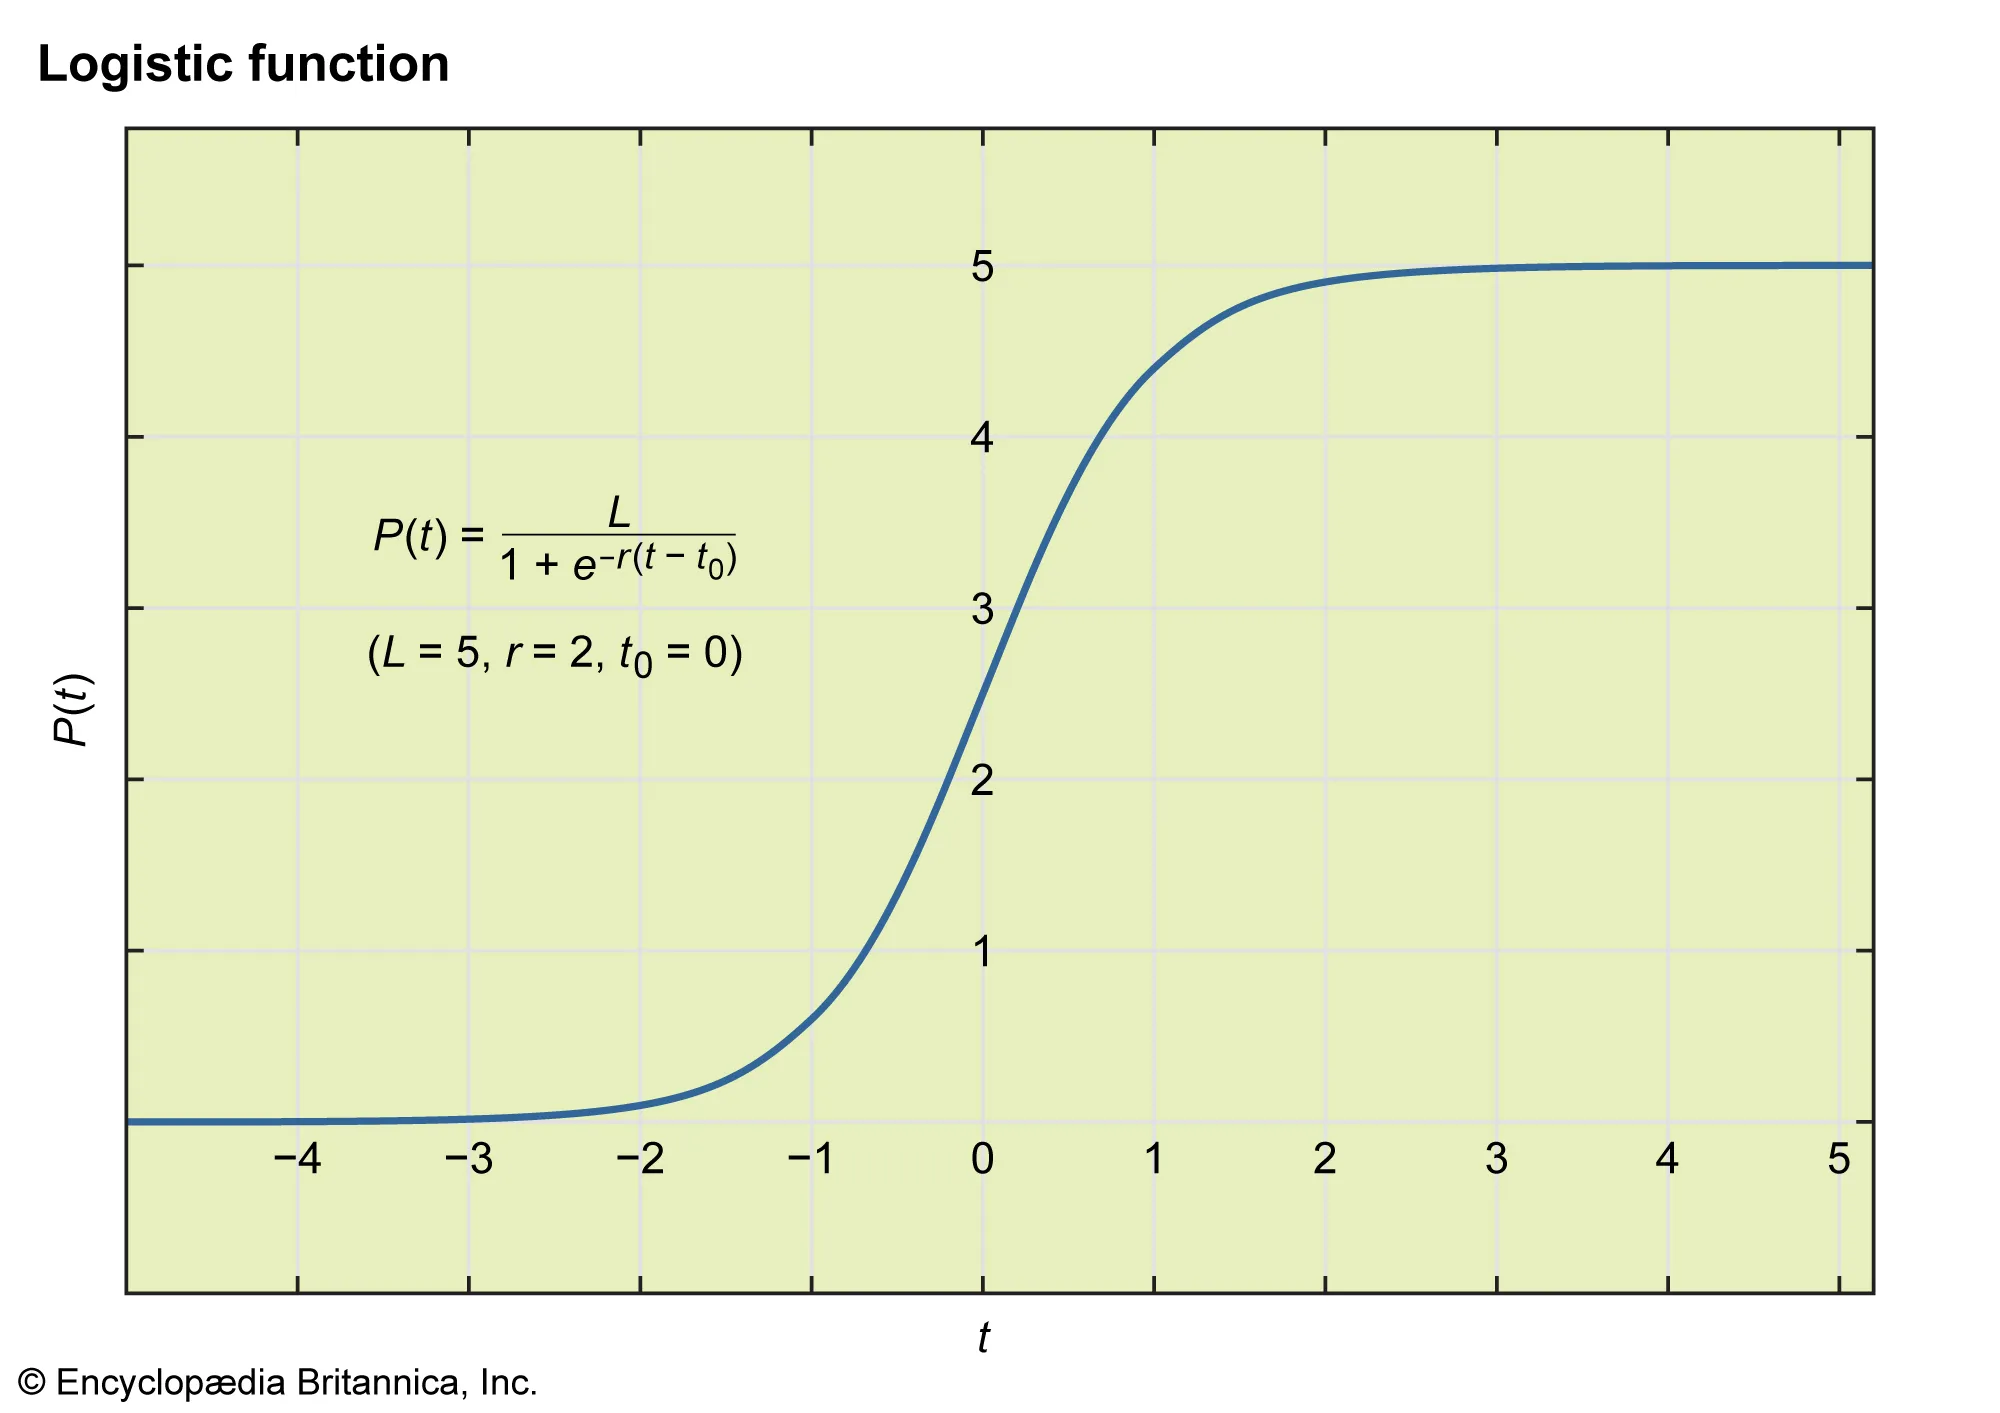

In [10]:
# 3. LOGISTIC MODEL FITTING
def logistic(t, L, k, t0):
    """Standard logistic growth function."""
    return L / (1 + np.exp(-k * (t - t0)))
 
# Fit on penetration data
t_data = df["year"].values.astype(float)
y_data = df["penetration"].values
 
# Initial guesses: L ~ 80%, k ~ 0.15, t0 ~ 2012
popt, pcov = curve_fit(logistic, t_data, y_data, p0=[80, 0.15, 2012], maxfev=10000)
L_fit, k_fit, t0_fit = popt
 
# R² score
y_pred = logistic(t_data, *popt)
ss_res = np.sum((y_data - y_pred) ** 2)
ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
r_squared = 1 - ss_res / ss_tot
 
print("LOGISTIC MODEL FIT")
print(f"  P(t) = L / (1 + e^(-k·(t - t₀)))")
print(f"  L  (saturation ceiling) = {L_fit:.2f}%")
print(f"  k  (growth rate)        = {k_fit:.4f}")
print(f"  t₀ (inflection point)   = {t0_fit:.1f}")
print(f"  R²                      = {r_squared:.4f}")
print()
 
# Generate predictions for projection
t_future = np.arange(1990, 2036)
y_future = logistic(t_future, *popt)

LOGISTIC MODEL FIT
  P(t) = L / (1 + e^(-k·(t - t₀)))
  L  (saturation ceiling) = 83.08%
  k  (growth rate)        = 0.1595
  t₀ (inflection point)   = 2014.8
  R²                      = 0.9929



The $R^2$ represent that the logistic curve explain 99.3% of the variance in penetration rate over 34 years.

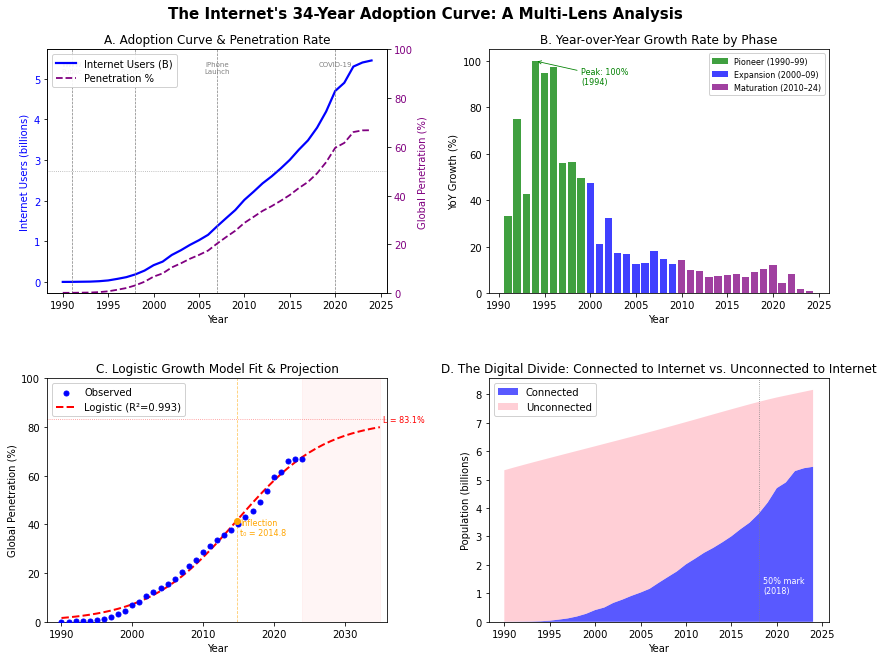

In [11]:
# 4. VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "The Internet's 34-Year Adoption Curve: A Multi-Lens Analysis",
    fontsize=15, fontweight="bold", y=0.98,
)
fig.subplots_adjust(hspace=0.35, wspace=0.3, top=0.92)
 

# Panel A: Adoption Curve with Milestones
ax = axes[0, 0]
ax.set_title("A. Adoption Curve & Penetration Rate")
 
ax.plot(df["year"], df["internet_users"] / 1e9, color="blue", linewidth=2.2, label="Internet Users (B)")
ax.set_ylabel("Internet Users (billions)", color="blue")
ax.set_xlabel("Year")
ax.tick_params(axis="y", labelcolor="blue")
 
ax2 = ax.twinx()
ax2.plot(df["year"], df["penetration"], color="purple", linewidth=1.8, linestyle="--", label="Penetration %")
ax2.axhline(50, color="gray", linestyle=":", linewidth=0.8, alpha=0.7)
ax2.set_ylabel("Global Penetration (%)", color="purple")
ax2.tick_params(axis="y", labelcolor="purple")
ax2.set_ylim(0, 100)
 
# Milestone annotations
MILESTONES = [
    (1991, "WWW\nPublic"),
    (1998, "Google\nFounded"),
    (2007, "iPhone\nLaunch"),
    (2020, "COVID-19"),
]

for yr, label in MILESTONES:
    ax.axvline(yr, color="gray", linestyle="--", linewidth=0.7)
    ax.text(yr, ax.get_ylim()[1] * 0.95, label, fontsize=7, ha="center",
            color="gray", va="top")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.9)
 
    
# Panel B: YoY Growth Rate
ax = axes[0, 1]
ax.set_title("B. Year-over-Year Growth Rate by Phase")

PHASE_COLORS = {
    "Pioneer (1990–99)": "green",
    "Expansion (2000–09)": "blue",
    "Maturation (2010–24)": "purple",
}

df_growth = df.dropna(subset=["yoy_growth"])
colors = [PHASE_COLORS.get(p, "gray") for p in df_growth["phase"]]
bars = ax.bar(df_growth["year"], df_growth["yoy_growth"], color=colors, alpha=0.75, width=0.8)
ax.set_ylabel("YoY Growth (%)")
ax.set_xlabel("Year")
ax.axhline(0, color="cyan", linewidth=0.5)
 
# Custom legend for phases
from matplotlib.patches import Patch
legend_items = [Patch(facecolor=c, alpha=0.75, label=n) for n, c in PHASE_COLORS.items()]
ax.legend(handles=legend_items, loc="upper right", fontsize=8, framealpha=0.9)
 
# Annotate peak
peak_idx = df_growth["yoy_growth"].idxmax()
peak_row = df_growth.loc[peak_idx]
ax.annotate(
    f"Peak: {peak_row['yoy_growth']:.0f}%\n({int(peak_row['year'])})",
    xy=(peak_row["year"], peak_row["yoy_growth"]),
    xytext=(peak_row["year"] + 5, peak_row["yoy_growth"] - 10),
    fontsize=8, color="green",
    arrowprops=dict(arrowstyle="->", color="green", lw=0.8),
)
 

#Panel C: Logistic S-Curve
ax = axes[1, 0]
ax.set_title("C. Logistic Growth Model Fit & Projection")
 
ax.scatter(df["year"], df["penetration"], color="blue", s=25, zorder=5, label="Observed")
ax.plot(t_future, y_future, color="red", linewidth=2, linestyle="--", label=f"Logistic (R²={r_squared:.3f})")
 
# Shade future projection
ax.axvspan(2024, 2035, alpha=0.04, color="red")
ax.axhline(L_fit, color="red", linewidth=0.8, linestyle=":", alpha=0.5)
ax.text(2035.5, L_fit, f"L = {L_fit:.1f}%", fontsize=8, color="red", va="center")
 
# Mark inflection point
ax.axvline(t0_fit, color="orange", linewidth=0.8, linestyle="--", alpha=0.6)
pen_at_inflection = logistic(t0_fit, *popt)
ax.plot(t0_fit, pen_at_inflection, "o", color="orange", markersize=6, zorder=6)
ax.text(t0_fit + 0.5, pen_at_inflection - 6, f"Inflection\nt₀ = {t0_fit:.1f}",
        fontsize=8, color="orange")
 
ax.set_ylabel("Global Penetration (%)")
ax.set_xlabel("Year")
ax.set_ylim(0, 100)
ax.set_xlim(1988, 2036)
ax.legend(loc="upper left", framealpha=0.9)
 

# Panel D: Digital Divide
ax = axes[1, 1]
ax.set_title("D. The Digital Divide: Connected to Internet vs. Unconnected to Internet")
 
ax.stackplot(
    df["year"],
    df["internet_users"] / 1e9,
    df["unconnected"] / 1e9,
    labels=["Connected", "Unconnected"],
    colors=["blue", "lightpink"],
    alpha=0.65,
)
ax.set_ylabel("Population (billions)")
ax.set_xlabel("Year")
ax.legend(loc="upper left", framealpha=0.9)
 
# Annotate crossover region
cross_year = df.loc[(df["penetration"] - 50).abs().idxmin(), "year"]
ax.axvline(cross_year, color="gray", linestyle=":", linewidth=0.8)
ax.text(cross_year + 0.5, 1, f"50% mark\n({int(cross_year)})", fontsize=8, color="white")
 
plt.show()